# Importation des bibliothèques

In [99]:
import pandas as pd
import numpy as np
import missingno as msno
import nltk
import re
import json
import os

from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import MultiLabelBinarizer

# Importation des fichier CSV

In [3]:
df_td = pd.read_csv(r"C:\Users\Utilisateur\Desktop\ProjetCertif\ProjetCertif\données_csv\travel_destinations.csv")
df_wtc = pd.read_csv(r"C:\Users\Utilisateur\Desktop\ProjetCertif\ProjetCertif\données_csv\Worldwide_Travel_Cities.csv")

# Analyse des différentes bases de données

## Valeurs nulls

### Base de données : Travel Destinations

<Axes: >

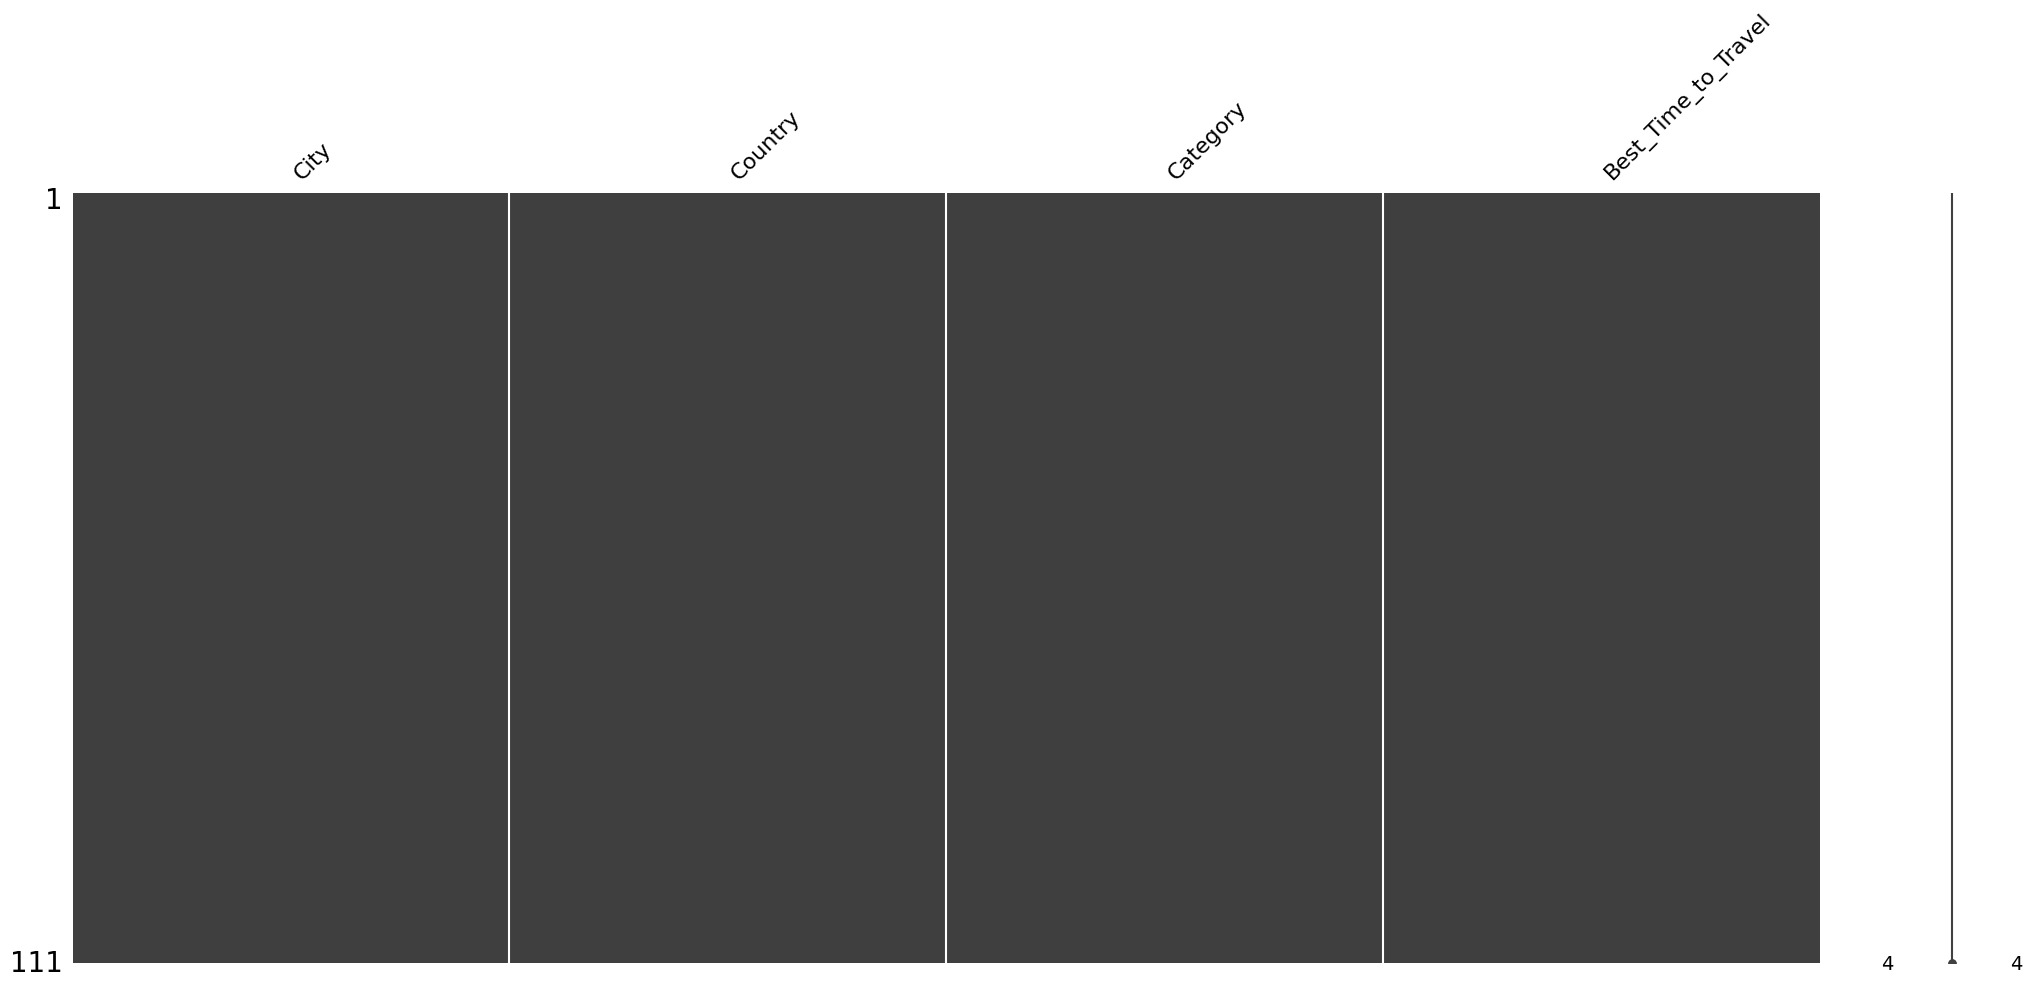

In [4]:
msno.matrix(df_td)

### Base de données : Worlwide Travel Cities

<Axes: >

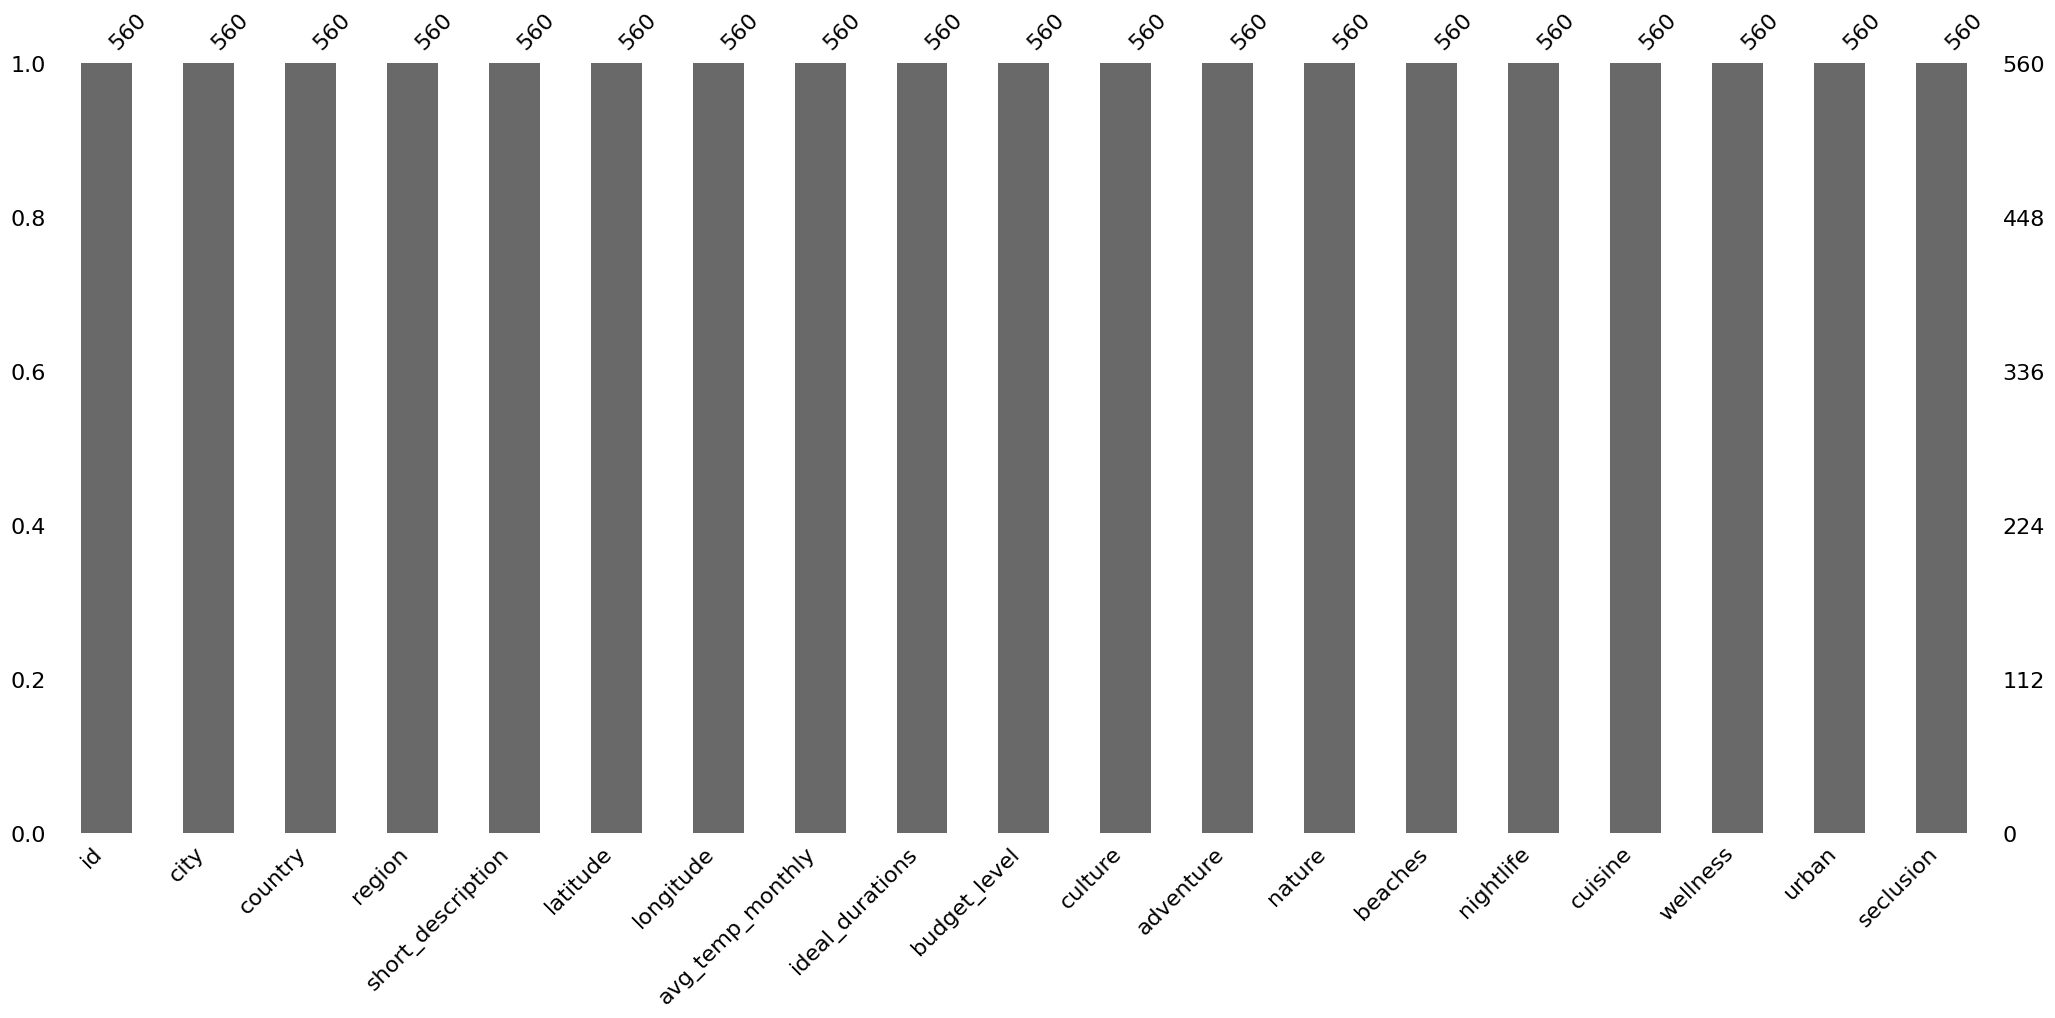

In [5]:
msno.bar(df_wtc)

Les 2 bases de données récupérés n'ont aucune valeurs nulls.

## Informations générales

### **Base de données :** Travel Destinations

In [6]:
df_td.head()

,City,Country,Category,Best_Time_to_Travel
0,London,United Kingdom,"history, culture, museums, theatre, shopping, ...","Apr, May, Jun, Sep, Oct"
1,Paris,France,"art, museums, landmarks, culture, history, foo...","Apr, May, Jun, Sep, Oct"
2,Rome,Italy,"history, ancient ruins, culture, art, food, re...","Apr, May, Jun, Sep, Oct"
3,Berlin,Germany,"history, culture, nightlife, art, museums, music","May, Jun, Jul, Aug, Sep"
4,Madrid,Spain,"art, museums, nightlife, food, culture, histor...","Apr, May, Jun, Sep, Oct"


**Première problématique :** utiliser str.get_dummies() sur les colonnes "Category" et "Best_Time_to_Travel" pour pouvoir les exploiter

In [7]:
df_td.describe()

,City,Country,Category,Best_Time_to_Travel
count,111,111,111,111
unique,111,44,111,54
top,London,USA,"history, culture, museums, theatre, shopping, ...","Apr, May, Jun, Sep, Oct"
freq,1,13,1,14


In [8]:
df_td.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   City                 111 non-null    str  
 1   Country              111 non-null    str  
 2   Category             111 non-null    str  
 3   Best_Time_to_Travel  111 non-null    str  
dtypes: str(4)
memory usage: 3.6 KB


### **Base de données :** Worldwide Travel Cities

In [9]:
df_wtc.head()

,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


**Premiere problématique :** utiliset one hot encoding pour la colonne "budget_level"

**Deuxième problématique :** utiliser str.get_dummies() pour la colonne "ideal_durations"

**Troisième problématique :** comment exploiter la colonne "avg_temp_monthly"

In [10]:
df_wtc.describe()

,latitude,longitude,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
count,560.000000,560.000000,560.00000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,22.502186,7.914665,3.85000,3.178571,3.728571,2.380357,3.019643,3.792857,3.073214,3.146429,3.028571
std,27.980022,78.813803,0.81291,0.798190,0.903920,1.435547,0.921599,0.679329,0.592134,1.018604,0.989699
min,-54.807306,-175.201808,2.00000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,5.268054,-64.439118,3.00000,3.000000,3.000000,1.000000,2.000000,3.000000,3.000000,2.000000,2.000000
50%,31.793618,10.711854,4.00000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000
75%,43.673199,50.020162,4.00000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000
max,78.719852,179.332896,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [11]:
df_wtc.info()

<class 'pandas.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 560 non-null    str    
 1   city               560 non-null    str    
 2   country            560 non-null    str    
 3   region             560 non-null    str    
 4   short_description  560 non-null    str    
 5   latitude           560 non-null    float64
 6   longitude          560 non-null    float64
 7   avg_temp_monthly   560 non-null    str    
 8   ideal_durations    560 non-null    str    
 9   budget_level       560 non-null    str    
 10  culture            560 non-null    int64  
 11  adventure          560 non-null    int64  
 12  nature             560 non-null    int64  
 13  beaches            560 non-null    int64  
 14  nightlife          560 non-null    int64  
 15  cuisine            560 non-null    int64  
 16  wellness           560 non-null    in

In [12]:
# création d'un nouveau df qui contient quelque colonnes de df_wtc
df_wtc_col_spec = df_wtc[["culture", "adventure", "nature", "beaches", "nightlife", "cuisine", "wellness", "urban", "seclusion"]]
df_wtc_col_spec

,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,5,2,2,1,4,5,3,5,2
1,2,4,5,5,2,3,4,1,5
2,3,5,5,2,3,3,4,2,4
3,5,3,3,1,3,4,3,4,2
4,4,3,3,2,3,4,3,4,2
...,...,...,...,...,...,...,...,...,...
555,3,5,5,1,2,3,3,2,4
556,4,3,4,3,3,4,3,4,3
557,4,2,2,1,4,4,3,4,2
558,5,2,3,2,4,4,3,5,2


In [13]:
for col in df_wtc_col_spec.columns:
    print(f"Colonne : {col}", df_wtc_col_spec[col].value_counts())

Colonne : culture culture
4    238
3    173
5    129
2     20
Name: count, dtype: int64
Colonne : adventure adventure
3    279
4    144
2    106
5     31
Name: count, dtype: int64
Colonne : nature nature
3    214
4    173
5    136
2     37
Name: count, dtype: int64
Colonne : beaches beaches
1    221
2    119
3     81
5     75
4     64
Name: count, dtype: int64
Colonne : nightlife nightlife
3    253
2    132
4    119
5     34
1     22
Name: count, dtype: int64
Colonne : cuisine cuisine
4    308
3    169
5     73
2     10
Name: count, dtype: int64
Colonne : wellness wellness
3    394
4     87
2     68
5     11
Name: count, dtype: int64
Colonne : urban urban
3    217
4    142
2    118
5     56
1     27
Name: count, dtype: int64
Colonne : seclusion seclusion
2    205
4    179
3    135
5     31
1     10
Name: count, dtype: int64


# Transformation des datasets

## **Base de données :** Travel Destinations

### Gestion de la colonne 'Category'

In [14]:
# j'enlève les éléments entre parenthèse
df_td['Category'] = df_td['Category'].str.replace(r'\(.*?\)', '', regex=True).str.strip()
df_td['Category']

0      history, culture, museums, theatre, shopping, ...
1      art, museums, landmarks, culture, history, foo...
2      history, ancient ruins, culture, art, food, re...
3       history, culture, nightlife, art, museums, music
4      art, museums, nightlife, food, culture, histor...
                             ...                        
106    history, colonial architecture , beach, cultur...
107    culture, religion , history, lake, botanical g...
108    mountains, hiking, tea plantations, scenery, t...
109    gateway to Sigiriya, gateway to Minneriya/Kaud...
110    beach, whale watching, surfing, relaxation, ni...
Name: Category, Length: 111, dtype: str

#### **Lemmatization** 
Pour eviter des 'doublons' avec des mots au pluriels et d'autre au singuliers entre chaque virgule

In [15]:
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_category(cat):
    return lemmatizer.lemmatize(cat.strip(), pos='n')

df_td['Category'] = df_td['Category'].apply(
    lambda row: ','.join([lemmatize_category(c) for c in row.split(',')])
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Utilisateur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### Dictionnaire

In [16]:
HIERARCHY = {
    # Culture
    "Afro-Brazilian culture": "culture",
    "Andean culture": "culture",
    "Javanese culture": "culture",
    "Lanna culture": "culture",
    "Latin culture": "culture",
    "Maori culture": "culture",
    "Polynesian culture": "culture",
    "French culture": "culture",
    "city culture": "culture",
    "modern culture": "culture",
    "pop culture": "culture",
    "beer culture": "culture",
    "coffee culture": "culture",
    "food culture": "culture",
    "culture": "culture",
    "hygge": "culture",
    "K-pop": "culture",
    "Bollywood": "culture",
    "flamenco": "culture",
    "tango": "culture",
    "Fado music": "culture",
    "geisha district": "culture",
    "batik": "culture",
    "silk weaving": "culture",
    "traditional arts": "culture",
    "comic": "culture",
    "royalty": "culture",

    # History
    "history": "history",
    "Portuguese history": "history",
    "Silk Road history": "history",
    "colonial history": "history",
    "industrial history": "history",
    "maritime history": "history",
    "music history": "history",
    "ancient ruins": "history",
    "Mayan ruins": "history",
    "archaeology": "history",
    "memorial": "history",
    "nearby Auschwitz/Salt Mines": "history",
    "oldest living city": "history",
    "ruin": "history",

    # Architecture & Urban
    "architecture": "architecture",
    "Art Deco architecture": "architecture",
    "European architecture": "architecture",
    "French colonial architecture": "architecture",
    "Mughal architecture": "architecture",
    "colonial architecture": "architecture",
    "colonial old town": "architecture",
    "medieval architecture": "architecture",
    "modern architecture": "architecture",
    "colourful architecture": "architecture",
    "charming architecture": "architecture",
    "Old City": "architecture",
    "Old Town": "architecture",
    "charming Old Town": "architecture",
    "medieval town": "architecture",
    "castle": "architecture",
    "city wall": "architecture",
    "fort": "architecture",
    "palace": "architecture",
    "monument": "architecture",
    "landmark": "architecture",
    "skyline": "architecture",
    "unique cityscape": "architecture",
    "modern bridges": "architecture",

    # Nature & Landscape
    "nature": "nature",
    "nature hub": "nature",
    "surrounding nature": "nature",
    "tropical nature": "nature",
    "scenery": "nature",
    "Andean scenery": "nature",
    "Andes mountains": "nature",
    "mountain": "nature",
    "hill": "nature",
    "volcano": "nature",
    "glacier": "nature",
    "fjord": "nature",
    "desert": "nature",
    "desert landscapes": "nature",
    "rainforest": "nature",
    "island": "nature",
    "archipelago": "nature",
    "cave": "nature",
    "salt flats": "nature",
    "rice paddies": "nature",
    "Marble Mountains": "nature",
    "unique geology": "nature",
    "northern lights": "nature",
    "geyser": "nature",
    "geothermal spas": "nature",
    "subtropical climate": "nature",
    "sunshine": "nature",
    "Tasmania": "nature",

    # Water & Coast
    "beach": "water & coast",
    "ocean": "water & coast",
    "coastline": "water & coast",
    "river": "water & coast",
    "river city": "water & coast",
    "lake": "water & coast",
    "lakefront": "water & coast",
    "canal": "water & coast",
    "harbour": "water & coast",
    "port city": "water & coast",
    "fishing harbour": "water & coast",
    "waterfall": "water & coast",
    "Ganges river": "water & coast",
    "Danube river": "water & coast",
    "Mekong Delta": "water & coast",
    "Halong Bay": "water & coast",
    "Avon River": "water & coast",
    "Great Ocean Road": "water & coast",
    "French Riviera": "water & coast",
    "Caribbean coast": "water & coast",

    # Outdoor Activities
    "adventure": "outdoor activities",
    "adventure sports": "outdoor activities",
    "hiking": "outdoor activities",
    "trekking": "outdoor activities",
    "trekking base": "outdoor activities",
    "skiing": "outdoor activities",
    "surfing": "outdoor activities",
    "diving": "outdoor activities",
    "snorkeling": "outdoor activities",
    "sailing": "outdoor activities",
    "cycling": "outdoor activities",
    "outdoors": "outdoor activities",
    "whale watching": "outdoor activities",
    "wildlife safaris": "outdoor activities",
    "desert safaris": "outdoor activities",
    "stargazing": "outdoor activities",
    "train journey": "outdoor activities",
    "cable cars": "outdoor activities",

    # Food & Drink
    "food": "food & drink",
    "dining": "food & drink",
    "seafood": "food & drink",
    "seafood markets": "food & drink",
    "dim sum": "food & drink",
    "chocolate": "food & drink",
    "coffee": "food & drink",
    "coffee houses": "food & drink",
    "tea houses": "food & drink",
    "tea plantations": "food & drink",
    "beer": "food & drink",
    "wine": "food & drink",
    "wine region": "food & drink",
    "wine regions": "food & drink",
    "mezcal": "food & drink",
    "market": "food & drink",
    "street markets": "food & drink",
    "bazaar": "food & drink",

    # Arts & Entertainment
    "art": "arts & entertainment",
    "street art": "arts & entertainment",
    "design": "arts & entertainment",
    "craft": "arts & entertainment",
    "music": "arts & entertainment",
    "live music": "arts & entertainment",
    "music venues": "arts & entertainment",
    "theatre": "arts & entertainment",
    "show": "arts & entertainment",
    "festival": "arts & entertainment",
    "film festival": "arts & entertainment",
    "carnival": "arts & entertainment",
    "snow festival": "arts & entertainment",
    "winter carnival": "arts & entertainment",
    "Stampede": "arts & entertainment",
    "entertainment": "arts & entertainment",
    "theme parks": "arts & entertainment",
    "literature": "arts & entertainment",

    # Religion & Spirituality
    "religion": "religion & spirituality",
    "spirituality": "religion & spirituality",
    "temple": "religion & spirituality",
    "mosque": "religion & spirituality",
    "shrine": "religion & spirituality",
    "Hindu rituals": "religion & spirituality",
    "mythology": "religion & spirituality",

    # Shopping & Lifestyle
    "shopping": "shopping & lifestyle",
    "luxury": "shopping & lifestyle",
    "leather goods": "shopping & lifestyle",
    "craft beer": "shopping & lifestyle",
    "pub": "shopping & lifestyle",
    "nightlife": "shopping & lifestyle",
    "party": "shopping & lifestyle",
    "gambling": "shopping & lifestyle",
    "romance": "shopping & lifestyle",
    "relaxation": "shopping & lifestyle",
    "relaxed city life": "shopping & lifestyle",
    "wellness": "shopping & lifestyle",
    "yoga": "shopping & lifestyle",
    "budget-friendly": "shopping & lifestyle",
    "family-friendly": "shopping & lifestyle",
    "resort": "shopping & lifestyle",

    # Urban Life
    "street life": "urban life",
    "laneways": "urban life",
    "promenade": "urban life",
    "diverse neighborhoods": "urban life",
    "walking city": "urban life",
    "capital city": "urban life",
    "EU capital": "urban life",
    "port city": "urban life",
    "windy city": "urban life",

    # Sport
    "sport": "sport",
    "football": "sport",
    "cricket": "sport",

    # Tech & Innovation
    "tech": "tech & innovation",
    "tech scene": "tech & innovation",
    "technology": "tech & innovation",
    "innovation": "tech & innovation",
    "rebuild/innovation": "tech & innovation",
    "finance": "tech & innovation",
    "academia": "tech & innovation",
    "oil industry": "tech & innovation",

    # Nature & Wildlife
    "elephant": "wildlife",
    "panda": "wildlife",

    # Geography & Gateways
    "gateway to Alps": "gateway",
    "gateway to Canadian Rockies": "gateway",
    "gateway to Galapagos": "gateway",
    "gateway to Gold Coast/Sunshine Coast": "gateway",
    "gateway to Great Barrier Reef": "gateway",
    "gateway to Himalayas": "gateway",
    "gateway to Hoi An/Hue": "gateway",
    "gateway to Machu Picchu": "gateway",
    "gateway to Minneriya/Kaudulla parks": "gateway",
    "gateway to Sigiriya": "gateway",
    "gateway to South Island": "gateway",
    "gateway to hill country": "gateway",

    # Misc
    "viewpoint": "scenery",
    "botanical gardens": "nature",
    "garden": "nature",
    "park": "nature",
    "gondola": "transport",
    "isolation": "nature",
    "equator line": "geography",
    "Antarctic centre": "geography",
    "transformation story": "history",
    "politics": "government",
    "government": "government",
    "traboules": "architecture",
    "thermal baths": "wellness",
    "geothermal spas": "wellness",
}

#### ????

In [17]:
def map_to_parents_count(cell):
    cats = [c.strip() for c in cell.split(',')]
    parents = [HIERARCHY.get(c, 'other') for c in cats]
    counts = {}
    for p in parents:
        counts[p] = counts.get(p, 0) + 1
    return counts

parent_counts = df_td['Category'].apply(map_to_parents_count)
parent_dummies = pd.DataFrame(parent_counts.tolist(), index=df_td.index).fillna(0).astype(int)

df_td = pd.concat([df_td, parent_dummies], axis=1)

In [18]:
# Création d'une nouvelle colonne 'category_count'
df_td['category_count'] = df_td['Category'].apply(lambda x: len(x.split(',')))
df_td = df_td.drop(columns=['Category'])

In [19]:
df_td

,City,Country,Best_Time_to_Travel,history,culture,other,arts & entertainment,shopping & lifestyle,architecture,food & drink,...,wellness,tech & innovation,wildlife,urban life,gateway,sport,transport,government,geography,category_count
0,London,United Kingdom,"Apr, May, Jun, Sep, Oct",1,2,1,1,2,1,0,...,0,0,0,0,0,0,0,0,0,8
1,Paris,France,"Apr, May, Jun, Sep, Oct",1,1,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,9
2,Rome,Italy,"Apr, May, Jun, Sep, Oct",2,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,7
3,Berlin,Germany,"May, Jun, Jul, Aug, Sep",1,1,1,2,1,0,0,...,0,0,0,0,0,0,0,0,0,6
4,Madrid,Spain,"Apr, May, Jun, Sep, Oct",1,1,1,1,2,0,1,...,0,0,0,0,0,0,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,Galle,Sri Lanka,"Dec, Jan, Feb, Mar",1,1,0,0,1,1,0,...,0,0,0,0,0,1,0,0,0,6
107,Kandy,Sri Lanka,"Dec, Jan, Feb, Mar, Apr",1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,6
108,Ella,Sri Lanka,"Jan, Feb, Mar, Jul, Aug, Sep",0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,7
109,Habarana,Sri Lanka,"Jan, Feb, Mar, Jul, Aug, Sep",0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,4


Pour le traitement de la colonne 'Category', j'ai crée un dictionnaire pour réunir les catégories dans des catégories plus larges. J'ai également créée une colonne qui compte le nombre de catégories par ligne.

### Gestion de la colonne 'Best_Time_to_Travel'

In [20]:
df_td['Best_Time_to_Travel']

0           Apr, May, Jun, Sep, Oct
1           Apr, May, Jun, Sep, Oct
2           Apr, May, Jun, Sep, Oct
3           May, Jun, Jul, Aug, Sep
4           Apr, May, Jun, Sep, Oct
                   ...             
106              Dec, Jan, Feb, Mar
107         Dec, Jan, Feb, Mar, Apr
108    Jan, Feb, Mar, Jul, Aug, Sep
109    Jan, Feb, Mar, Jul, Aug, Sep
110    Nov, Dec, Jan, Feb, Mar, Apr
Name: Best_Time_to_Travel, Length: 111, dtype: str

#### Dictionnaire

In [21]:
MONTH_DIC = {
    'Jan': 1, 
    'Feb': 2, 
    'Mar': 3, 
    'Apr': 4,
    'May': 5, 
    'Jun': 6, 
    'Jul': 7, 
    'Aug': 8,
    'Sep': 9, 
    'Oct': 10, 
    'Nov': 11, 
    'Dec': 12,

    'jan': 1, 
    'feb': 2, 
    'mar': 3, 
    'apr': 4, 
    'may': 5,
    'jun': 6, 
    'jul': 7, 
    'aug': 8,
    'sep': 9, 
    'oct': 10, 
    'nov': 11, 
    'dec': 12, '(dec':12
}

#### Séparation des mois

In [22]:
def clean_months(cell):
    # Enlever tout ce qui est entre parenthèses
    cleaned = re.sub(r'\(.*?\)', '', str(cell))
    # Enlever les espaces superflus et séparer
    return ','.join([m.strip() for m in cleaned.split(',') if m.strip()])

df_td['Best_Time_to_Travel'] = df_td['Best_Time_to_Travel'].apply(clean_months)

In [23]:
def clean_months(cell):
    cleaned = re.sub(r'\(.*?\)', '', str(cell))  # parenthèses normales
    cleaned = re.sub(r'\w+\)', '', cleaned)        # parenthèse fermante orpheline
    return ','.join([m.strip() for m in cleaned.split(',') if m.strip()])

In [24]:
all_vals = set()
for cell in df_td['Best_Time_to_Travel']:
    for m in str(cell).split(','):
        all_vals.add(m.strip().lower())

unknown = [v for v in all_vals if v not in MONTH_DIC]
print(sorted(unknown))

[]


In [25]:
mlb = MultiLabelBinarizer()

month_dummies = pd.DataFrame(
    mlb.fit_transform(df_td['Best_Time_to_Travel'].apply(
        lambda x: [MONTH_DIC[m.strip().lower()] for m in x.split(',') if m.strip().lower() in MONTH_DIC]
    )),
    columns=[f'month_{c}' for c in mlb.classes_],
    index=df_td.index
)

df_td = pd.concat([df_td, month_dummies], axis=1)


In [26]:
# Création d'une nouvelle colonne 'category_count'
df_td['month_count'] = df_td['Best_Time_to_Travel'].apply(lambda x: len(x.split(',')))
df_td = df_td.drop(columns=['Best_Time_to_Travel'])

In [27]:
df_td.dtypes

City                         str
Country                      str
history                    int64
culture                    int64
other                      int64
arts & entertainment       int64
shopping & lifestyle       int64
architecture               int64
food & drink               int64
religion & spirituality    int64
water & coast              int64
outdoor activities         int64
nature                     int64
scenery                    int64
wellness                   int64
tech & innovation          int64
wildlife                   int64
urban life                 int64
gateway                    int64
sport                      int64
transport                  int64
government                 int64
geography                  int64
category_count             int64
month_1                    int64
month_2                    int64
month_3                    int64
month_4                    int64
month_5                    int64
month_6                    int64
month_7   

## **BILAN**

La colonne 'category' a été supprimé pour faire place a des colonnes 'parentes' pour limiter le nombre de catégories. Il y a aussi un conteur par ville de catégories culturelles.

La colonne 'Best_Time_to_Travel', qui listait les mois idéaux pour voyager, a été supprimer au profit d'une colonne par mois (bool). Il y a également une colonne qui compte le nombre de mois optimaux pour voyager.

In [28]:
df_td.shape

(111, 37)

## **Base de données :** Worldwide Travel Cities

In [29]:
df_wtc.dtypes

id                       str
city                     str
country                  str
region                   str
short_description        str
latitude             float64
longitude            float64
avg_temp_monthly         str
ideal_durations          str
budget_level             str
culture                int64
adventure              int64
nature                 int64
beaches                int64
nightlife              int64
cuisine                int64
wellness               int64
urban                  int64
seclusion              int64
dtype: object

### Gestion de la colonne 'budget_level'

In [30]:
df_wtc['budget_level'].value_counts()

budget_level
Mid-range    339
Budget       145
Luxury        76
Name: count, dtype: int64

#### Dictionnaire et changement de valeurs

In [31]:
BUDGET_NUM = {
    'Budget': 1,
    'Mid-range': 2,
    'Luxury': 3
}

df_wtc['budget_level'] = df_wtc['budget_level'].map(BUDGET_NUM)

In [32]:
df_wtc['budget_level'].value_counts()

budget_level
2    339
1    145
3     76
Name: count, dtype: int64

✅ **La colonne contient des valeurs numériques :**
    
1 = budget

2 = mid_range

3 = luxury

### Gestion de la colonne 'ideal_durations'

In [33]:
df_wtc['ideal_durations'].value_counts()

ideal_durations
["Short trip","Weekend","One week"]      120
["Short trip","Weekend"]                 115
["Weekend","One week","Short trip"]       53
["Short trip","One week"]                 49
["One week","Short trip","Weekend"]       46
["Short trip","One week","Weekend"]       39
["One week","Short trip"]                 37
["Weekend","Short trip"]                  22
["Long trip","One week"]                  14
["Long trip","One week","Short trip"]     14
["Short trip","One week","Long trip"]     10
["One week","Weekend","Short trip"]        6
["Weekend","Short trip","Day trip"]        5
["One week","Long trip"]                   5
["Long trip","Short trip","One week"]      5
["Short trip","Long trip","One week"]      5
["Short trip","Weekend","Day trip"]        4
["Weekend","Day trip"]                     4
["Day trip","Weekend","Short trip"]        3
["Day trip","Weekend"]                     2
["Weekend","Day trip","Short trip"]        2
Name: count, dtype: int64

**OBJECTIF :** faire une colonne bool par duréés

=> enlever, les crochets, enlever les guillemets et séparer avec le séparateurs ','

#### Supprimetion de ' [, ], " '

In [34]:
df_wtc['ideal_durations'] = df_wtc['ideal_durations'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('"', '', regex=False)
df_wtc['ideal_durations']

0              Short trip,One week
1               Long trip,One week
2      Short trip,Weekend,One week
3      Weekend,One week,Short trip
4               Short trip,Weekend
                  ...             
555            One week,Short trip
556    Weekend,One week,Short trip
557    Weekend,One week,Short trip
558    One week,Short trip,Weekend
559    Short trip,Weekend,One week
Name: ideal_durations, Length: 560, dtype: str

#### Création de colonnes booléennes

In [35]:
df_wtc_dummed = df_wtc['ideal_durations'].str.get_dummies(sep=',')
df_wtc_dummed

,Day trip,Long trip,One week,Short trip,Weekend
0,0,0,1,1,0
1,0,1,1,0,0
2,0,0,1,1,1
3,0,0,1,1,1
4,0,0,0,1,1
...,...,...,...,...,...
555,0,0,1,1,0
556,0,0,1,1,1
557,0,0,1,1,1
558,0,0,1,1,1


In [36]:
df_wtc_dummed.shape

(560, 5)

In [37]:
df_wtc_clean = pd.concat([df_wtc, df_wtc_dummed], axis=1)
df_wtc_clean = df_wtc_clean.drop(columns=['ideal_durations'])
df_wtc_clean

,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,budget_level,culture,...,nightlife,cuisine,wellness,urban,seclusion,Day trip,Long trip,One week,Short trip,Weekend
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...",3,5,...,4,5,3,5,2,0,0,1,1,0
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...",3,2,...,2,3,4,1,5,0,1,1,0,0
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...",3,3,...,3,3,4,2,4,0,0,1,1,1
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...",2,5,...,3,4,3,4,2,0,0,1,1,1
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...",1,4,...,3,4,3,4,2,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,778d28df-a4fa-4328-896e-4a9f80216fda,Maun,Botswana,africa,"A gateway to the Okavango Delta, offering a se...",-19.986095,23.422435,"{""1"":{""avg"":26.6,""max"":32,""min"":21.2},""2"":{""av...",2,3,...,2,3,3,2,4,0,0,1,1,0
556,44fb18eb-2641-46ab-b3fa-df6870ba3c74,Gothenburg,Sweden,europe,"A charming city with picturesque canals, lush ...",57.707233,11.967017,"{""1"":{""avg"":1.4,""max"":3.2,""min"":-1.2},""2"":{""av...",2,4,...,3,4,3,4,3,0,0,1,1,1
557,8c8c7203-2a45-44ba-9fb2-b5158104375e,Manchester,United Kingdom,europe,"Industrial heritage meets modern creativity, w...",53.479489,-2.245115,"{""1"":{""avg"":4.7,""max"":7.1,""min"":2},""2"":{""avg"":...",2,4,...,4,4,3,4,2,0,0,1,1,1
558,ba72b976-10f9-4415-a818-32cf17d8e649,Copenhagen,Denmark,europe,"Charming canals, vibrant neighborhoods, and a ...",55.686724,12.570072,"{""1"":{""avg"":2.6,""max"":4.2,""min"":0.6},""2"":{""avg...",2,5,...,4,4,3,5,2,0,0,1,1,1


✅ **La colonne s'est tranformé en 5 colonnes bools**

### Gestion de la colonne 'avg_temp_monthly'

In [38]:
df_wtc_clean['avg_temp_monthly']

0      {"1":{"avg":3.7,"max":7.8,"min":0.4},"2":{"avg...
1      {"1":{"avg":28,"max":30.8,"min":25.8},"2":{"av...
2      {"1":{"avg":-2.5,"max":0.4,"min":-5.5},"2":{"a...
3      {"1":{"avg":15.5,"max":22.8,"min":8.7},"2":{"a...
4      {"1":{"avg":28.1,"max":32.5,"min":25.5},"2":{"...
                             ...                        
555    {"1":{"avg":26.6,"max":32,"min":21.2},"2":{"av...
556    {"1":{"avg":1.4,"max":3.2,"min":-1.2},"2":{"av...
557    {"1":{"avg":4.7,"max":7.1,"min":2},"2":{"avg":...
558    {"1":{"avg":2.6,"max":4.2,"min":0.6},"2":{"avg...
559    {"1":{"avg":15.4,"max":19.8,"min":10.2},"2":{"...
Name: avg_temp_monthly, Length: 560, dtype: str

**Problèmes :**

- Séparation par _mois_
- Est ce que je concerve toutes les données de température ou seulement la moyenne par mois ?

In [39]:
# 1. Parser la string JSON en dict
df_wtc_clean['avg_temp_monthly'] = df_wtc_clean['avg_temp_monthly'].apply(json.loads)

# 2. Aplatir le dict en colonnes
temp_df = pd.json_normalize(df_wtc_clean['avg_temp_monthly'])

# 3. Renommer les colonnes : "1.avg" → "temp_month1_avg"
temp_df.columns = [f"temp_month{col.replace('.', '_')}" for col in temp_df.columns]

# 4. Concat et supprimer la colonne originale
df_wtc_clean = pd.concat([df_wtc_clean.reset_index(drop=True), temp_df], axis=1)
df_wtc_clean = df_wtc_clean.drop(columns=['avg_temp_monthly'])
df_wtc_clean.dtypes

id                       str
city                     str
country                  str
region                   str
short_description        str
latitude             float64
longitude            float64
budget_level           int64
culture                int64
adventure              int64
nature                 int64
beaches                int64
nightlife              int64
cuisine                int64
wellness               int64
urban                  int64
seclusion              int64
Day trip               int64
Long trip              int64
One week               int64
Short trip             int64
Weekend                int64
temp_month1_avg      float64
temp_month1_max      float64
temp_month1_min      float64
temp_month2_avg      float64
temp_month2_max      float64
temp_month2_min      float64
temp_month3_avg      float64
temp_month3_max      float64
temp_month3_min      float64
temp_month4_avg      float64
temp_month4_max      float64
temp_month4_min      float64
temp_month5_av

## **BILAN**
- 'budget_level' à été transformé en colonne numérique
- get_dummies a été appliqué sur 'ideal_durations' => 5 colonnes bool
- 3*12 nouvelles colonnes a la place de 'avg_temp_monthly' pour pouvoir exploiter les données de cette colonne

In [40]:
df_wtc_clean.shape

(560, 58)

# ❌ Unification des datasets

Je vais pouvoir **réunir les deux datasets sur la colonne city**. Je déciderais ensuite ce que je fais des différences de dimension des bases de données et des 'doublons' de colonnes culturels (je pense supprimer les éléments culturels du dataset df_wtc_clean)

**Premier probleme :** 'city' et 'City'

In [52]:
df_wtc_clean = df_wtc_clean.rename(columns={'city': 'City'})

In [53]:
df_final = df_td.merge(df_wtc_clean, on='City', how='outer')
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 94 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   City                     575 non-null    str    
 1   Country                  111 non-null    str    
 2   history                  111 non-null    float64
 3   culture_x                111 non-null    float64
 4   other                    111 non-null    float64
 5   arts & entertainment     111 non-null    float64
 6   shopping & lifestyle     111 non-null    float64
 7   architecture             111 non-null    float64
 8   food & drink             111 non-null    float64
 9   religion & spirituality  111 non-null    float64
 10  water & coast            111 non-null    float64
 11  outdoor activities       111 non-null    float64
 12  nature_x                 111 non-null    float64
 13  scenery                  111 non-null    float64
 14  wellness_x               111 non-null

**Deuxième probleme :** vérifier les colonnes 'doubles'
- 'country' & 'Country'

In [76]:
df_final['new'] = df_final['country'].isin(df_final['Country'])
df_final['new'].value_counts()

new
True     309
False    266
Name: count, dtype: int64

In [78]:
visu = df_final[['country', 'Country', 'new']][df_final['new'] == False]
visu

,country,Country,new
3,Ghana,NaN,False
7,Egypt,NaN,False
9,Kazakhstan,NaN,False
10,Jordan,NaN,False
13,United States,NaN,False
...,...,...,...
565,United States,NaN,False
568,Croatia,NaN,False
570,Tanzania,NaN,False
571,Tanzania,NaN,False


In [58]:
visu['Country'].value_counts()

Country
USA      12
China     1
Name: count, dtype: int64

In [60]:
visu_plus = visu[visu['Country'] == 'USA']
visu_plus

,country,Country,new
32,United States,USA,False
71,United States,USA,False
115,United States,USA,False
144,United States,USA,False
213,United States,USA,False
261,United States,USA,False
277,United States,USA,False
319,United States,USA,False
352,United States,USA,False
354,United States,USA,False


In [61]:
visu_plu = visu[visu['Country'] == 'China']
visu_plu

,country,Country,new
211,Hong Kong,China,False


On peut **supprimer la colonne 'Country'** sans inquiétudes, les différences sont soit :
- des valeurs nulls
- des valeurs qui sontsimilaires/identiques

In [83]:
# supprimer aussi la colonne 'new'
df_final_clean = df_final.drop(columns = ['new', 'Country'])
df_final_clean.columns

Index(['City', 'history', 'culture_x', 'other', 'arts & entertainment',
       'shopping & lifestyle', 'architecture', 'food & drink',
       'religion & spirituality', 'water & coast', 'outdoor activities',
       'nature_x', 'scenery', 'wellness_x', 'tech & innovation', 'wildlife',
       'urban life', 'gateway', 'sport', 'transport', 'government',
       'geography', 'category_count', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'month_count', 'id', 'country',
       'region', 'short_description', 'latitude', 'longitude', 'budget_level',
       'culture_y', 'adventure', 'nature_y', 'beaches', 'nightlife', 'cuisine',
       'wellness_y', 'urban', 'seclusion', 'Day trip', 'Long trip', 'One week',
       'Short trip', 'Weekend', 'temp_month1_avg', 'temp_month1_max',
       'temp_month1_min', 'temp_month2_avg', 'temp_month2_max',
       'temp_month2_min', 'temp_month3_avg', 'temp_mont

**Troisième problème :** supprimer les colonnes non nécéssaires (les concerver dans un autre dataset)
- 'short_description'

In [89]:
df_description = df_final[['region', 'country', 'City', 'short_description']]
df_description.head()

,region,country,City,short_description
0,europe,Denmark,Aarhus,Charming streets lined with modern architectur...
1,middle_east,United Arab Emirates,Abu Dhabi,Modern skyscrapers meet serene desert landscap...
2,north_america,Mexico,Acapulco,"Golden beaches meet vibrant nightlife, where t..."
3,africa,Ghana,Accra,"Lively streets filled with vibrant markets, rh..."
4,oceania,Australia,Adelaide,Charming streets lined with historic buildings...


In [86]:
df_final_clean = df_final_clean.drop(['short_description'], axis = 1)

KeyError: "['short_description'] not found in axis"

In [87]:
df_final_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 92 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   City                     575 non-null    str    
 1   history                  111 non-null    float64
 2   culture_x                111 non-null    float64
 3   other                    111 non-null    float64
 4   arts & entertainment     111 non-null    float64
 5   shopping & lifestyle     111 non-null    float64
 6   architecture             111 non-null    float64
 7   food & drink             111 non-null    float64
 8   religion & spirituality  111 non-null    float64
 9   water & coast            111 non-null    float64
 10  outdoor activities       111 non-null    float64
 11  nature_x                 111 non-null    float64
 12  scenery                  111 non-null    float64
 13  wellness_x               111 non-null    float64
 14  tech & innovation        111 non-null

<Axes: >

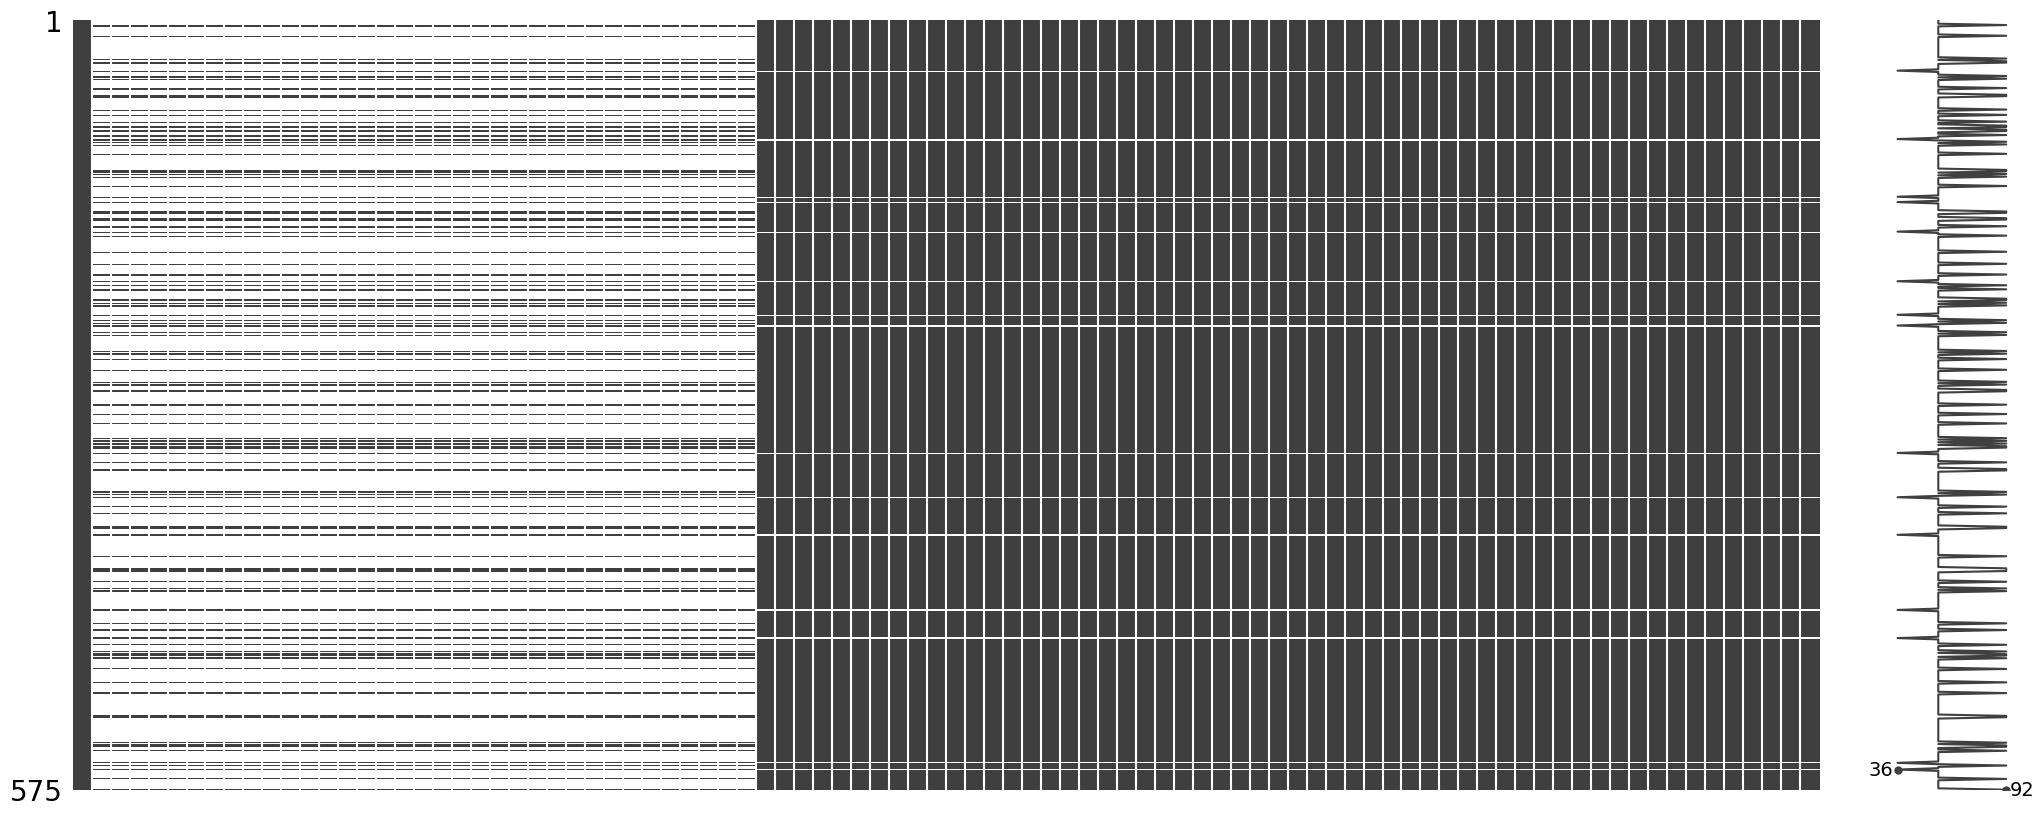

In [90]:
msno.matrix(df_final_clean)

# **_BILAN FINAL_**

La base de donnée _df_wtc_clean est suffisante_, les informations des 2 bdd sont redondantes autant concerver la plus complète.

df_description reste utile pour l'agrémentation de l'app.

## Exportation des bases de données

In [92]:
df_wtc_clean.columns

Index(['id', 'City', 'country', 'region', 'short_description', 'latitude',
       'longitude', 'budget_level', 'culture', 'adventure', 'nature',
       'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion',
       'Day trip', 'Long trip', 'One week', 'Short trip', 'Weekend',
       'temp_month1_avg', 'temp_month1_max', 'temp_month1_min',
       'temp_month2_avg', 'temp_month2_max', 'temp_month2_min',
       'temp_month3_avg', 'temp_month3_max', 'temp_month3_min',
       'temp_month4_avg', 'temp_month4_max', 'temp_month4_min',
       'temp_month5_avg', 'temp_month5_max', 'temp_month5_min',
       'temp_month6_avg', 'temp_month6_max', 'temp_month6_min',
       'temp_month7_avg', 'temp_month7_max', 'temp_month7_min',
       'temp_month8_avg', 'temp_month8_max', 'temp_month8_min',
       'temp_month9_avg', 'temp_month9_max', 'temp_month9_min',
       'temp_month10_avg', 'temp_month10_max', 'temp_month10_min',
       'temp_month11_avg', 'temp_month11_max', 'temp_month11_min',


In [98]:
# Dernières modification de la bdd de descripption
df_description = df_wtc_clean[["id", "region", "country", "City", "short_description"]]

# Dernières modificationt de la bdd ML
df_ml = df_wtc_clean.drop(columns=["id", "region", "country", "City", "short_description"])

,latitude,longitude,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,...,temp_month9_min,temp_month10_avg,temp_month10_max,temp_month10_min,temp_month11_avg,temp_month11_max,temp_month11_min,temp_month12_avg,temp_month12_max,temp_month12_min
0,45.464194,9.189635,3,5,2,2,1,4,5,3,...,16.1,15.2,19.6,11.5,8.8,12.5,5.6,4.7,8.2,1.9
1,-17.290947,177.125786,3,2,4,5,5,2,3,4,...,24.5,26.0,30.5,19.0,27.1,31.0,24.8,28.2,31.9,26.0
2,50.117190,-122.954302,3,3,5,5,2,3,3,4,...,9.9,7.6,11.6,4.4,1.8,5.1,-1.6,-1.8,0.9,-2.5
3,20.987700,-101.000000,2,5,3,3,1,3,4,3,...,13.9,19.0,26.2,12.6,17.7,25.5,10.7,14.9,22.1,9.2
4,-7.245972,112.737827,1,4,3,3,2,3,4,3,...,25.4,29.8,35.1,26.2,29.6,34.0,26.4,28.7,33.2,25.8


In [100]:
os.makedirs("BDD/CSV", exist_ok=True)

# Base de données déscriptives
df_description.to_csv("BDD/CSV/df_description.csv")

# Base de données Machine Learning
df_ml.to_csv("BDD/CSV/df_ml.csv")